In [2]:
import re
import matplotlib
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import nist_helper
import io
from IPython.display import Image, display
import utils
import nist_codes
import generic_render

In [3]:
X_MIN = 400
X_MAX = 750
FIG_SIZE = (15,3)
MIN_NEEDLE_WIDTH = 0.1
MAX_NEEDLE_WIDTH = 0.3
DPI = 600
MAX_Y_SCALE = 0.75
NEEDLE_POWER_SHAPE = 4
LABEL_NORM_INT = 0.20
GLOW_WIDTH_MULT = 1.3

NORM_PROM_PERC = 0.15
NORM_MIN_BRIGHT = 0.01
NORM_GLOW_ALPHA = 0
NORM_PEAK_EMPHASIS = 1.1
NORM_PEAK_LABEL_POSN = 0.75

DEFAULT_PROM_PERC = 0.08
DEFAULT_MIN_BRIGHT = 0.1
DEFAULT_GLOW_ALPHA = 0.35
DEFAULT_PEAK_EMPHASIS = 1.4
DEFAULT_PEAK_LABEL_POSN = 0.77

detection_col = '_raw_int'
int_col = '_adj_int'

In [4]:
def plot_spec(
    data_df,
    nm_col=None,
    int_col=None,
    prominence_percentage=0,
    x_min=X_MIN,
    x_max=X_MAX,
    fig_size=FIG_SIZE,
    min_brightness=0,
    save_path=None,
    min_needle_max_width_nm=MIN_NEEDLE_WIDTH,
    max_needle_max_width_nm=MAX_NEEDLE_WIDTH,
    needle_shape_power=NEEDLE_POWER_SHAPE,
    glow_width_multiplier=GLOW_WIDTH_MULT,
    glow_alpha=0,
    dpi=DPI,
    mode='dark',
    peak_label_y_position=0,
    max_needle_y_scale=MAX_Y_SCALE,
    peak_wavelengths=None,
    force_nist=None,
    apply_descriptor_adjustments=False,
    show_peak_labels=True,
    label_min_norm_int=LABEL_NORM_INT,
    generic_type=None
):
    # Resolve column names at runtime (accept many common aliases)
    if nm_col is None:
        nm_col = utils.resolve_column(data_df, utils.lambda_tokens, "wavelength",)
    if int_col is None:
        int_col = utils.resolve_column(data_df, utils.int_tokens, "intensity",)

    # Always parse NIST-style intensity cells first because descriptors are usually attached.
    df_plot_data = data_df.copy()
    df_plot_data[nm_col] = pd.to_numeric(df_plot_data[nm_col], errors='coerce')

    # run NIST detector
    has_any_nist, nist_diag = nist_codes.detect_nist_values(df_plot_data[int_col], force_nist=force_nist)

    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, int_col, apply_descriptor_adjustments)
        min_brightness = DEFAULT_MIN_BRIGHT
        glow_alpha = DEFAULT_GLOW_ALPHA
        prominence_percentage = DEFAULT_PROM_PERC
        peak_label_y_position = DEFAULT_PEAK_LABEL_POSN
        print('NIST Destriptors Detected. Preparing NIST Rendering.')

    else:
        df_plot_data = generic_render.prepare_generic_spectrum(df_plot_data, int_col, apply_descriptor_adjustments)
        print('No NIST Destriptors Detected. Preparing Generic Rendering.')
        generic_type = (input('Choose Rendering: Raw or Normalised')).lower()
        if generic_type == 'raw':
            glow_alpha = DEFAULT_GLOW_ALPHA
            peak_label_y_position = DEFAULT_PEAK_LABEL_POSN
        elif generic_type == 'normalised':
            glow_alpha = NORM_GLOW_ALPHA
            peak_label_y_position = NORM_PEAK_LABEL_POSN

        # parse NIST-style cells
    parsed_intensity = df_plot_data[int_col].apply(nist_codes.parse_nist_intensity)
    df_plot_data['_raw_int'] = parsed_intensity.apply(lambda t: t[0])
    df_plot_data['_descriptor'] = parsed_intensity.apply(lambda t: t[1])

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[nm_col, '_raw_int']).copy()
    df_plot_data = df_plot_data[(df_plot_data[nm_col] >= x_min) & (df_plot_data[nm_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=nm_col).reset_index(drop=True)

    # returns empty figure for empty datasets
    if df_plot_data.empty:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        return fig

    # Normalize using the adjusted intensity
    min_int_val = df_plot_data['_adj_int'].min()
    max_int_val = df_plot_data['_adj_int'].max()
    int_range = max_int_val - min_int_val
    if int_range == 0 or np.isnan(int_range):
        df_plot_data['Norm_Int'] = 1.0
    else:
        df_plot_data['Norm_Int'] = (df_plot_data['_adj_int'] - min_int_val) / int_range

    if peak_wavelengths is not None:
        nm_vals = df_plot_data[nm_col].values
        peaks = []
        for pw in peak_wavelengths:
            try:
                pv = float(pw)
            except Exception:
                continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        peaks = sorted(set(peaks))
    elif has_any_nist:
        peaks = nist_codes.identify_spectral_peaks(df_plot_data.reset_index(drop=True), prominence_percentage, peak_wavelengths=None)
    else:
        raw_min = df_plot_data[detection_col].min()
        raw_max = df_plot_data[detection_col].max()
        raw_range = raw_max - raw_min
        if generic_type=='raw':
            prominence_percentage = DEFAULT_PROM_PERC
        if generic_type == 'normalised':
            prominence_percentage = NORM_PROM_PERC
        dynamic_prominence = prominence_percentage * (raw_range if raw_range != 0 else 1.0)
        peaks, _ = find_peaks(df_plot_data[int_col], prominence=dynamic_prominence)
    
    peak_nms = [float(df_plot_data.iloc[index][nm_col]) for index in peaks]
    peak_ints = [float(df_plot_data.iloc[index]["Norm_Int"]) for index in peaks]
    try:
        label_ys = utils.compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=peak_label_y_position,
            min_sep_nm=0.4,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.90,
        )
    except Exception:
        label_ys = [peak_label_y_position] * len(peaks)
    
    print(f"DEBUG: max_label_y = {max(label_ys) if label_ys else 'N/A'}")

    # Create the plot (use explicit Figure/Axis to avoid side-effects)
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)



    max_label_y = max(label_ys) if label_ys else peak_label_y_position
    print(f"DEBUG: max_label_y = {max_label_y:.3f}, fig height = {fig.get_figheight():.2f}")

    # More aggressive expansion
    ylim_upper = max(1.05, max_label_y + 0.25)
    ax.set_ylim(0, ylim_upper)
    fig.set_figheight(fig_size[1] + 0.8)
    print(f"DEBUG: new ylim upper = {ylim_upper:.3f}, new fig height = {fig.get_figheight():.2f}")

        # Set figure background and text colors based on mode
    if mode == 'dark':
        figure_bg_color = 'black'
        text_color = 'white'
    else:  # light mode
        figure_bg_color = 'white'
        text_color = 'black'

    fig.patch.set_facecolor(figure_bg_color)
    ax.set_facecolor('black')  # Always keep the spectrum plot area (axes) background black

    # Remove Y-axis completely as intensity is shown by brightness/color
    ax.yaxis.set_visible(False)

    # Set X-axis labels and color
    ax.set_xlabel('Wavelength (nm)', color=text_color)

    # Set major and minor tick locators
    ax.xaxis.set_major_locator(utils.major_locator)
    ax.xaxis.set_minor_locator(utils.minor_locator)

    # Set tick parameters for both major and minor ticks
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)

    # Set X-axis limits
    ax.set_xlim(x_min, x_max)

    ax.set_ylim(0,1)

    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[nm_col])
        _ni = float(_row.get('Norm_Int', 0.0))
        _base_rgb = utils.wavelength_to_rgb(_nm)
        _final_scale = min_brightness + (1 - min_brightness) * _ni
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = _bg_base_width * np.ones_like(_bg_y)
        _x_left = _nm - _bg_widths / 2
        _x_right = _nm + _bg_widths / 2
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=glow_alpha, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][nm_col]
        peak_norm_int = df_plot_data.iloc[peak_index]['Norm_Int']

        # Get base RGB color for the peak wavelength
        base_rgb = utils.wavelength_to_rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        if has_any_nist or generic_type == 'raw':
            _peak_emphasis = DEFAULT_PEAK_EMPHASIS
            min_brightness = DEFAULT_MIN_BRIGHT
        elif generic_type == 'normalised':
            _peak_emphasis = NORM_PEAK_EMPHASIS
            min_brightness = NORM_MIN_BRIGHT
        pre_int_scale = min_brightness + (1 - min_brightness) * (peak_norm_int ** _peak_gamma)
        final_int_scale = min(1.0, pre_int_scale * _peak_emphasis)

        colored_rgb = (
            base_rgb[0] * final_int_scale,
            base_rgb[1] * final_int_scale,
            base_rgb[2] * final_int_scale,
        )

        # Scale the maximum width of the needle based on normalized intensity

        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm_int
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)
        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost

        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (
            y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render)
        )

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = peak_nm - glow_current_widths_nm / 2
        glow_x_right = peak_nm + glow_current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=colored_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = scaled_max_width_nm * width_profile_factor
        x_left = peak_nm - current_widths_nm / 2
        x_right = peak_nm + current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=colored_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        if show_peak_labels and peak_norm_int >= label_min_norm_int:
            y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
            ax.text(
                peak_nm,
                y_for_label,
                f"{peak_nm:.2f}",
                color="white",
                ha="left",
                va="bottom",
                fontsize=8,
                rotation=60,
                rotation_mode="anchor",
                zorder=3,
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

    if has_any_nist or generic_type == 'raw':
        pad = 15
    else:
        pad = 10
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.title(f'Emission Spectrum Visualization ({mode.capitalize()} Mode)', 
          color=text_color, y=0.98, pad=pad)

    # Save the plot if a save_path is provided
    if save_path:
        try:
            fig.savefig(save_path, facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=dpi)
        except Exception:
            plt.savefig(save_path, facecolor=plt.gcf().get_facecolor(), bbox_inches='tight', dpi=dpi)

    return fig

In [5]:
def get_spec(*args, save_path=None, headless=True, dpi=600, **kwargs):
    if headless:
        matplotlib.use('Agg')

    fig = plot_spec(*args, **kwargs)

    if save_path:
        try:
            fig.savefig(save_path, facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=dpi)
        except Exception:
            plt.savefig(save_path, facecolor=plt.gcf().get_facecolor(), bbox_inches='tight', dpi=dpi)

    if headless:
        plt.close(fig)

    return fig

NIST Destriptors Detected. Preparing NIST Rendering.
DEBUG: max_label_y = 0.9
DEBUG: max_label_y = 0.900, fig height = 3.00
DEBUG: new ylim upper = 1.150, new fig height = 3.80
NIST Destriptors Detected. Preparing NIST Rendering.
DEBUG: max_label_y = 0.9
DEBUG: max_label_y = 0.900, fig height = 3.00
DEBUG: new ylim upper = 1.150, new fig height = 3.80
fig size (in): [15.   3.8]
fig.dpi: 600
expected pixels (w,h): (9000, 2280)
saved image pixels (w,h): (8940, 2148)
saved bytes: 676931


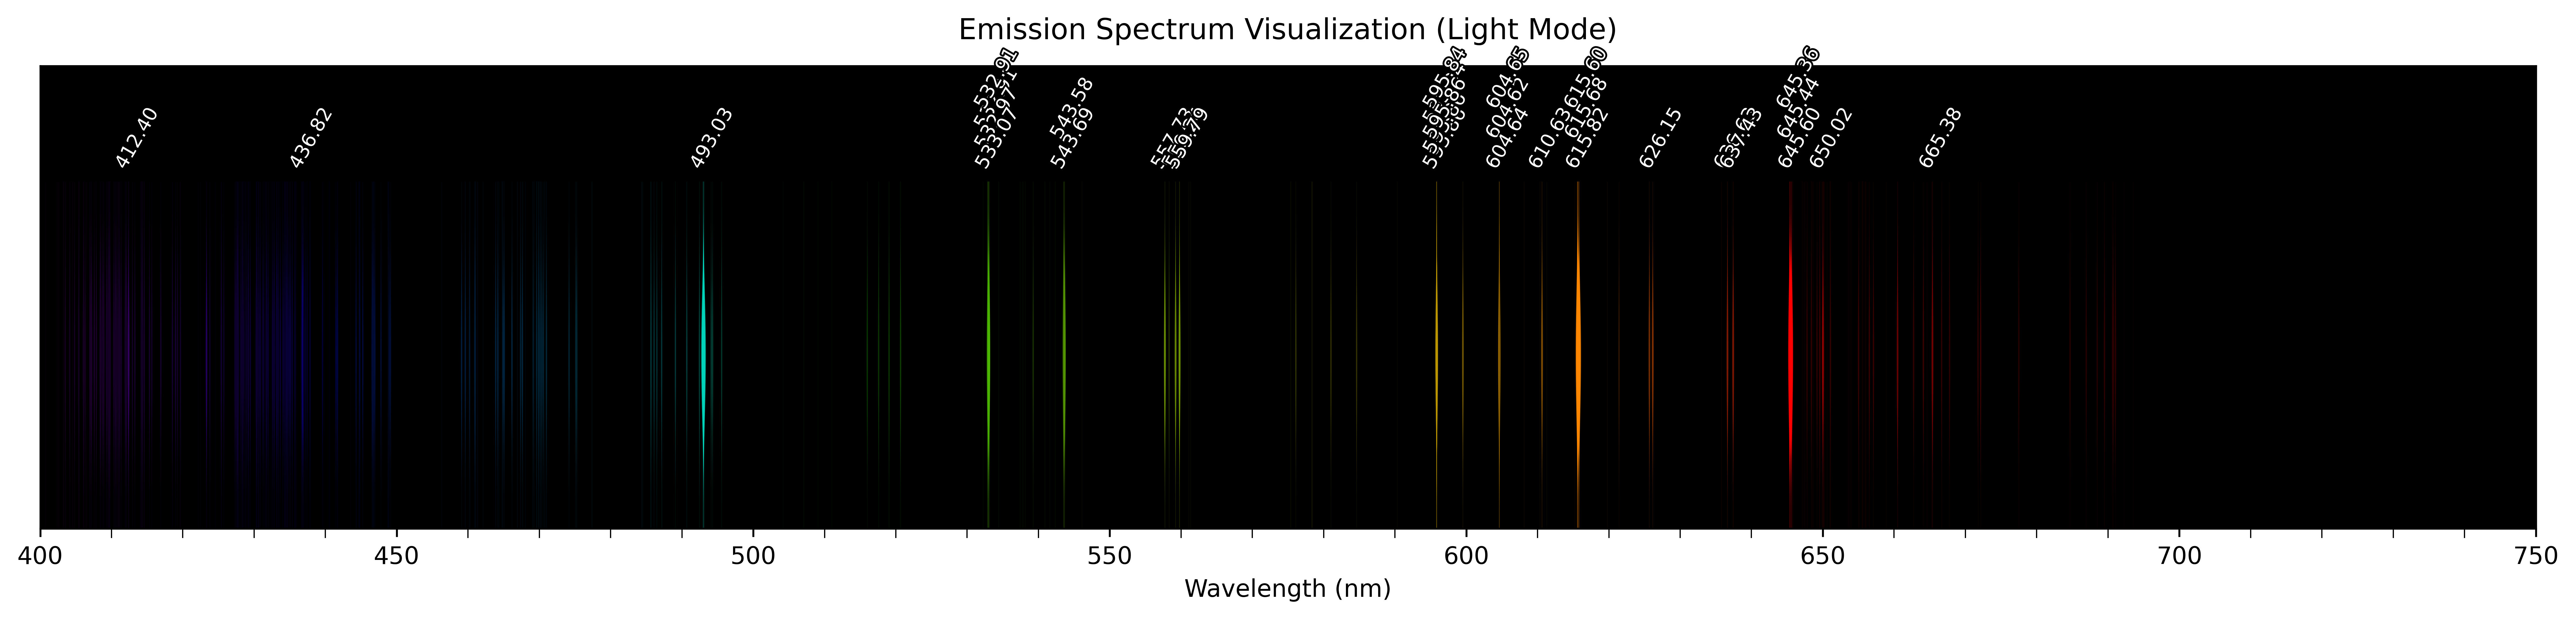

In [6]:
NIST_FILE_PATH = 'oxygen nist 2.xlsx'
HELIUM_FILE_PATH = 'he test.xlsx'
HYDROGEN_FILE_PATH = 'h test.xlsx'

df_nist = pd.read_excel(NIST_FILE_PATH)
df_he = pd.read_excel(HELIUM_FILE_PATH)
df_h = pd.read_excel(HYDROGEN_FILE_PATH)

nist_fig = get_spec(data_df=df_nist)
light_fig = plot_spec(data_df=df_nist, mode='light')

buf = io.BytesIO()
light_fig.savefig(buf, format='png', bbox_inches='tight', dpi=600)

from PIL import Image as PILImage
buf.seek(0)
img = PILImage.open(buf)
print("fig size (in):", light_fig.get_size_inches())
print("fig.dpi:", getattr(light_fig, "dpi", None))
print("expected pixels (w,h):", tuple(int(x * light_fig.dpi) for x in light_fig.get_size_inches()))
print("saved image pixels (w,h):", img.size)
print("saved bytes:", len(buf.getvalue()))

display(Image(data=buf.getvalue()))

No NIST Destriptors Detected. Preparing Generic Rendering.


DEBUG: max_label_y = 0.77
DEBUG: max_label_y = 0.770, fig height = 3.00
DEBUG: new ylim upper = 1.050, new fig height = 3.80
Before savefig: fig height = 3.800"
fig size (in): [15.   3.8]
fig.dpi: 600
expected pixels (w,h): (9000, 2280)
saved image pixels (w,h): (8940, 2205)
saved bytes: 290595


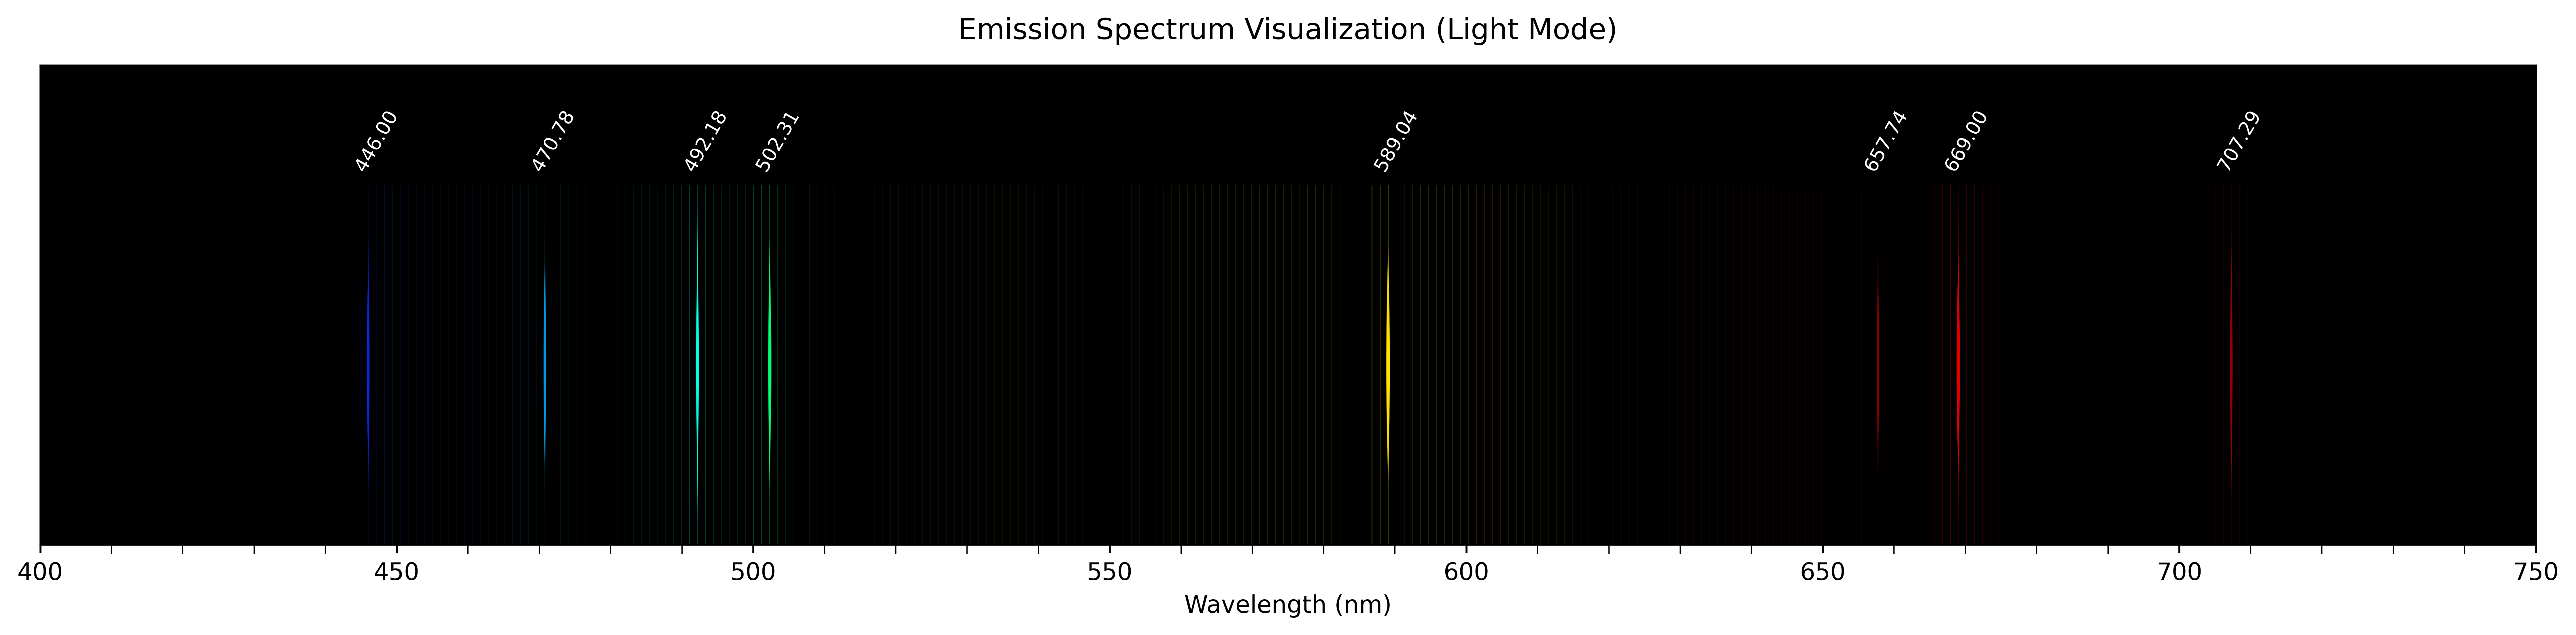

In [12]:
he_fig = get_spec(data_df=df_he, mode='light')

buf = io.BytesIO()

print(f"Before savefig: fig height = {he_fig.get_figheight():.3f}\"")
he_fig.savefig(buf, format='png', bbox_inches='tight', dpi=600)

from PIL import Image as PILImage
img = PILImage.open(buf)
print("fig size (in):", he_fig.get_size_inches())
print("fig.dpi:", getattr(he_fig, "dpi", None))
print("expected pixels (w,h):", tuple(int(x * he_fig.dpi) for x in he_fig.get_size_inches()))
print("saved image pixels (w,h):", img.size)
print("saved bytes:", len(buf.getvalue()))

plt.close(he_fig)
buf.seek(0)

display(Image(data=buf.getvalue()))



No NIST Destriptors Detected. Preparing Generic Rendering.
DEBUG: max_label_y = 0.75
DEBUG: max_label_y = 0.750, fig height = 3.00
DEBUG: new ylim upper = 1.050, new fig height = 3.80
No NIST Destriptors Detected. Preparing Generic Rendering.
DEBUG: max_label_y = 0.75
DEBUG: max_label_y = 0.750, fig height = 3.00
DEBUG: new ylim upper = 1.050, new fig height = 3.80
fig size (in): [15.   3.8]
fig.dpi: 600
expected pixels (w,h): (9000, 2280)
saved image pixels (w,h): (8940, 2163)
saved bytes: 192458


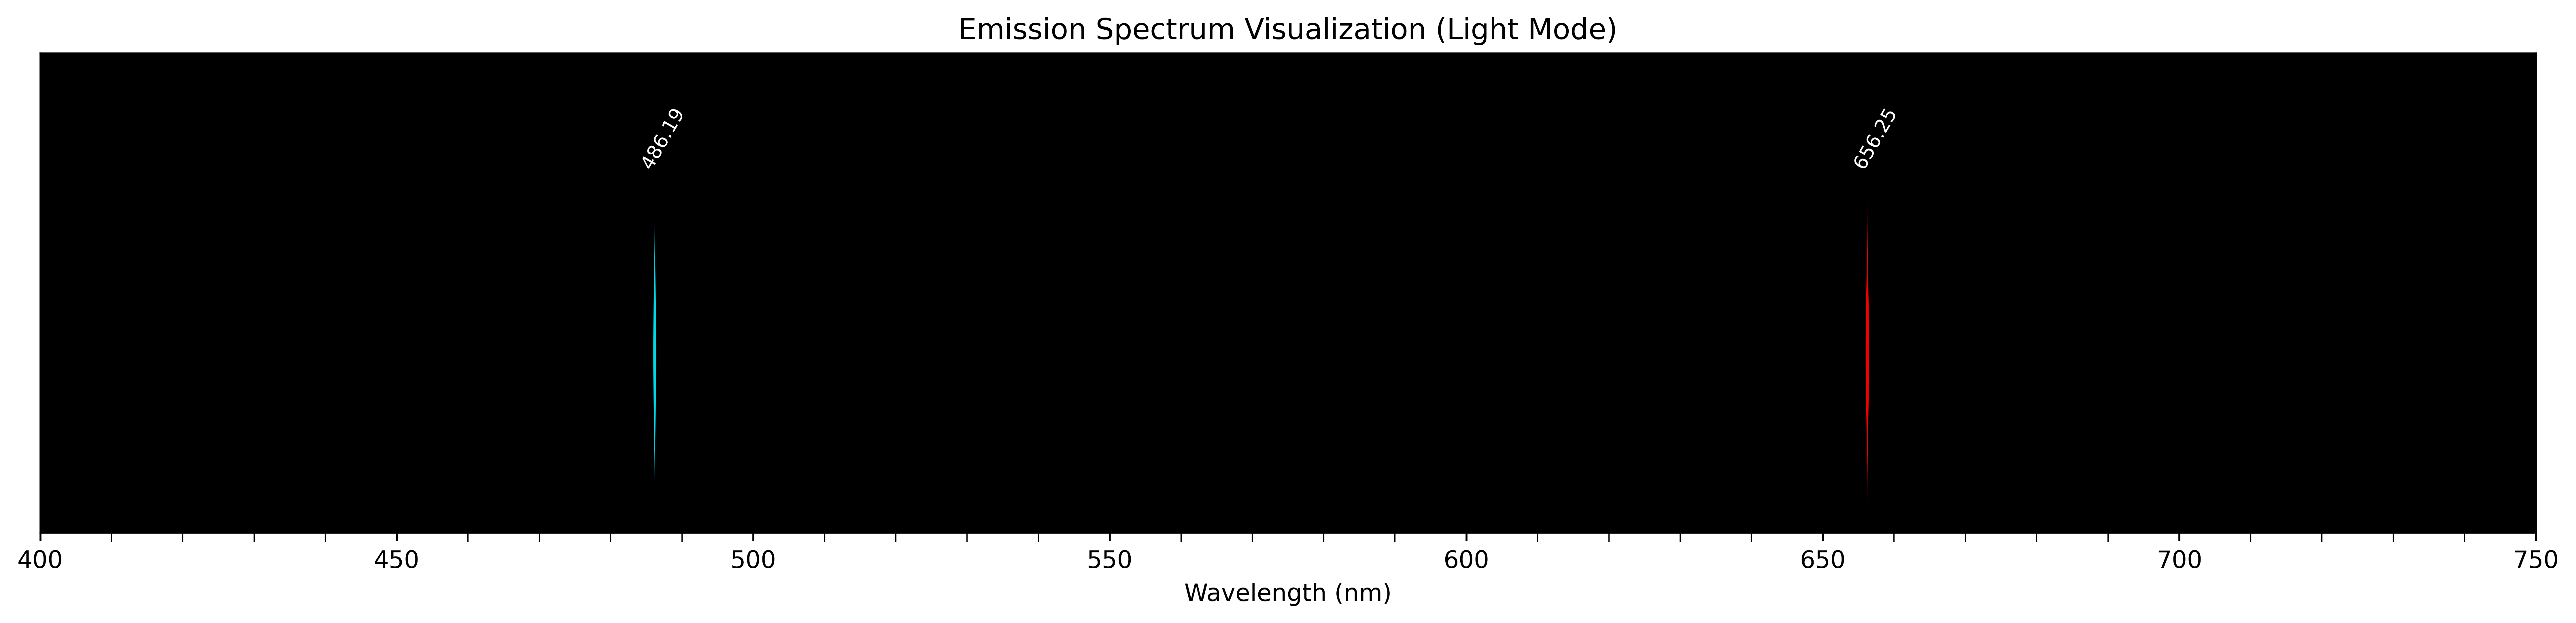

In [8]:
light_fig = plot_spec(data_df=df_h, mode='light')

h_fig = get_spec(data_df=df_h, mode='light')

buf = io.BytesIO()
h_fig.savefig(buf, format='png', bbox_inches='tight', dpi=600)
from PIL import Image as PILImage
buf.seek(0)
img = PILImage.open(buf)

print("fig size (in):", h_fig.get_size_inches())
print("fig.dpi:", getattr(h_fig, "dpi", None))
print("expected pixels (w,h):", tuple(int(x * h_fig.dpi) for x in h_fig.get_size_inches()))
print("saved image pixels (w,h):", img.size)
print("saved bytes:", len(buf.getvalue()))
display(Image(data=buf.getvalue()))

NIST Destriptors Detected. Preparing NIST Rendering.
DEBUG: max_label_y = 0.9
DEBUG: max_label_y = 0.900, fig height = 4.00
DEBUG: new ylim upper = 1.150, new fig height = 4.80
Height: 4.3", max label y: 0.900


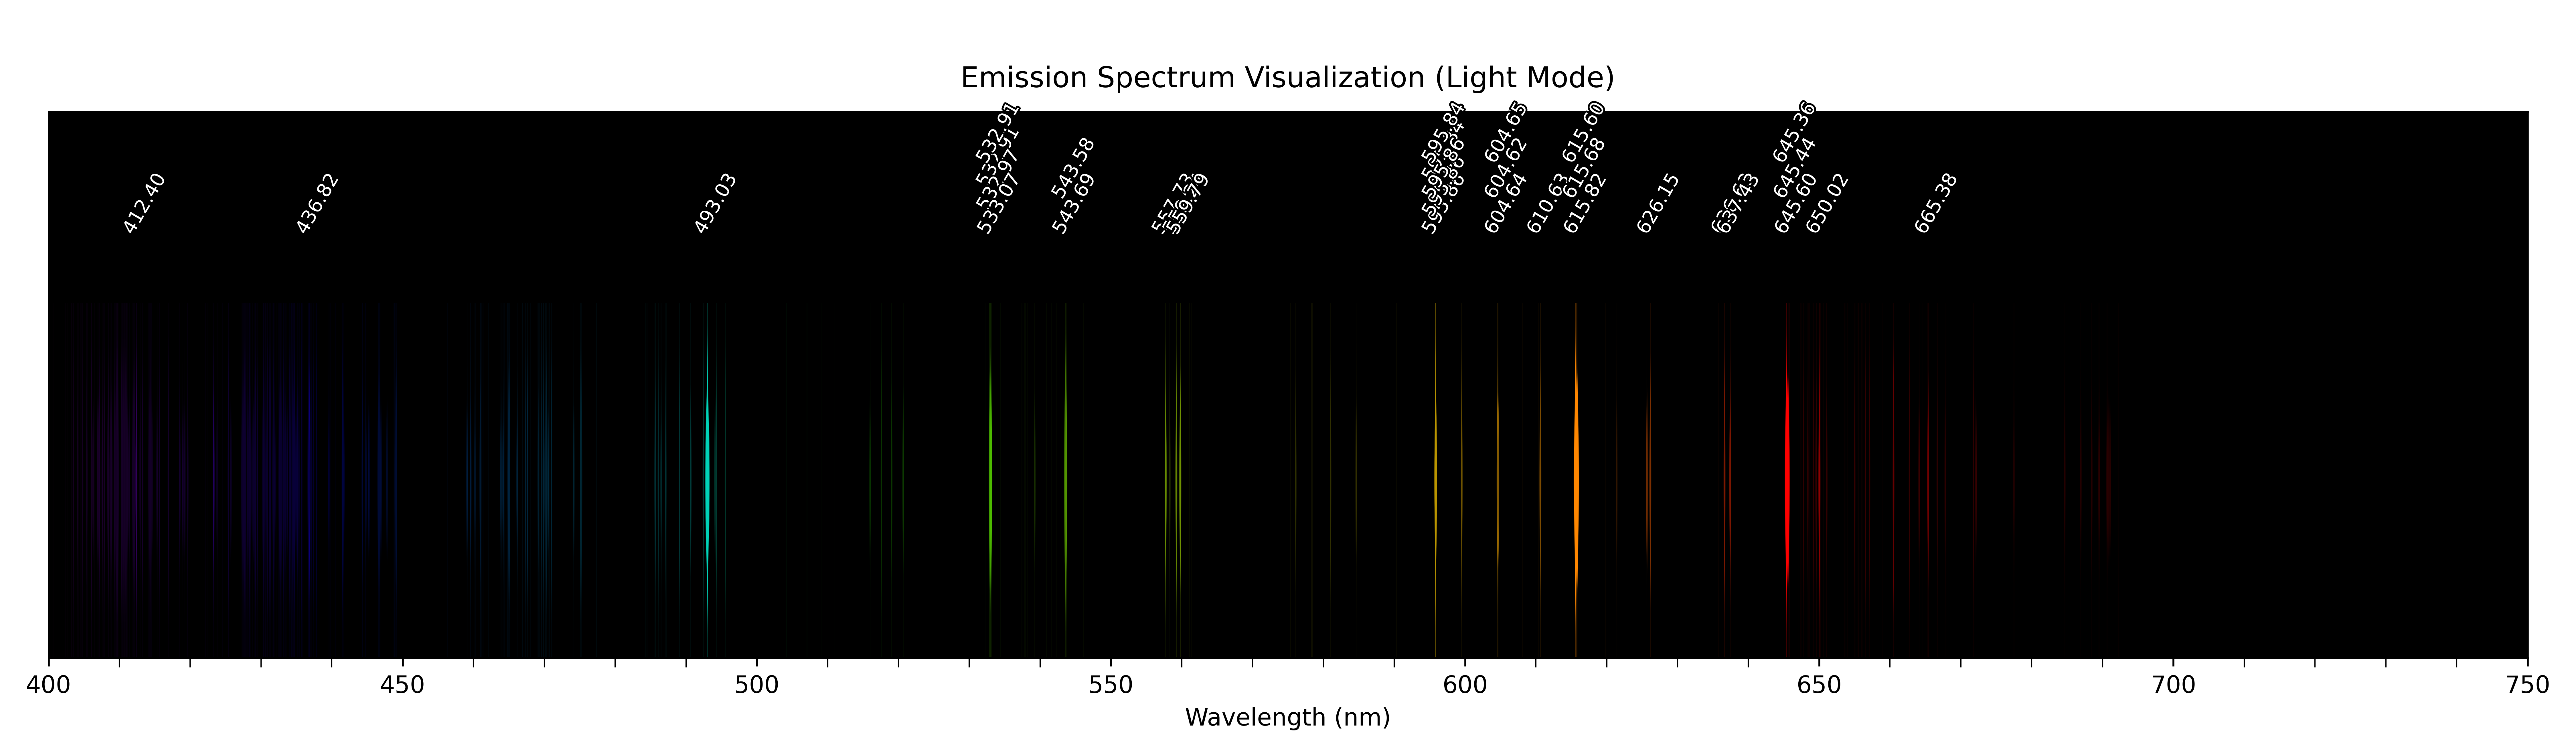

In [9]:
# ============================================================
# PLAYGROUND: tweak these values to adjust label spacing
# and dynamic figure expansion
# ============================================================

# --- DATA ---
EXCEL_FILE_PATH = 'oxygen nist 2.xlsx'
df = pd.read_excel(EXCEL_FILE_PATH)

# --- LABEL STACKING SETTINGS ---
peak_label_y_position = 0.55   # where labels sit by default (0.0–1.0)
min_sep_nm = 0.4               # horizontal gap (nm) before labels start stacking
y_step = 0.08                  # vertical gap between stacked labels
label_max_y = 0.50             # hard ceiling for stacking
label_method = "prefer_stronger_top"

# --- DYNAMIC EXPANSION SETTINGS ---
fig_width = 15
fig_height_base = 4.0          # starting figure height (inches)
fig_height_overflow_scale = 1.0  # extra inches per unit of overflow
ylim_buffer = 0.25             # extra space above highest label
subplots_adjust_top = 0.85     # fraction of figure used by axes (0.85 = 15% top padding)

# --- RENDER SETTINGS (pass-through) ---
prominence_percentage = 0.12
min_needle_max_width_nm = 0.1
max_needle_max_width_nm = 0.3
glow_width_multiplier = 1.3
glow_alpha = 0.35
mode = 'light'
max_needle_y_scale = 0.65
min_brightness = 0.1
needle_shape_power = 4
label_min_norm_int = 0.20

# --- RENDER ---
fig = plot_spec(
    data_df=df,
    prominence_percentage=prominence_percentage,
    x_min=400, x_max=750,
    min_needle_max_width_nm=min_needle_max_width_nm,
    max_needle_max_width_nm=max_needle_max_width_nm,
    glow_width_multiplier=glow_width_multiplier,
    glow_alpha=glow_alpha,
    mode=mode,
    peak_label_y_position=peak_label_y_position,
    max_needle_y_scale=max_needle_y_scale,
    fig_size=(fig_width, fig_height_base),
    min_brightness=min_brightness,
    needle_shape_power=needle_shape_power,
    label_min_norm_int=label_min_norm_int,
)

# --- DYNAMIC ADJUSTMENT (after render) ---
ax = fig.axes[0]


# Extract peak wavelengths and intensities from the rendered data
# (we re-use what the plot function already computed internally)

# Simpler: just measure from the actual labels on the plot
label_ys = [
    child.get_position()[1]
    for child in ax.get_children()
    if isinstance(child, matplotlib.text.Text)
    and child.get_text().replace('.','',1).replace('-','').isdigit()
]

max_label_y = max(label_ys) if label_ys else peak_label_y_position

# Expand if needed
if max_label_y > peak_label_y_position + 0.05:
    overflow = max_label_y - peak_label_y_position
    new_height = fig_height_base + overflow * fig_height_overflow_scale
    fig.set_figheight(new_height)
    # Give the axes room at the top for labels + title
    print(f"Height: {fig.get_figheight():.1f}\", max label y: {max_label_y:.3f}")
else:
    print(f"No expansion (max_label_y={max_label_y:.3f})")

plt.subplots_adjust(top=subplots_adjust_top)

# --- DISPLAY ---
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=600)
buf.seek(0)
display(Image(data=buf.getvalue()))